In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.shape
df.isnull().mean()*100
df.describe()
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [4]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='str')

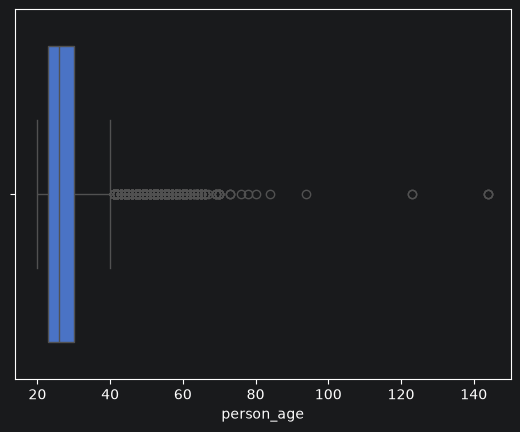

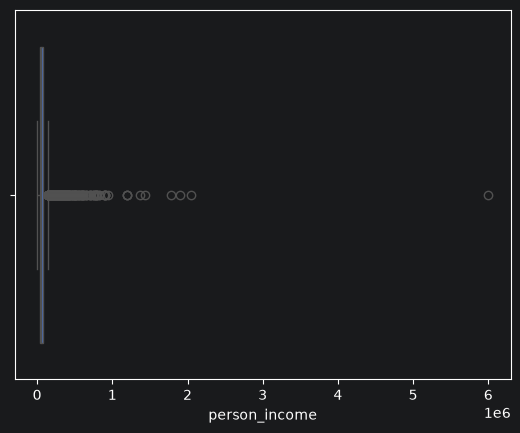

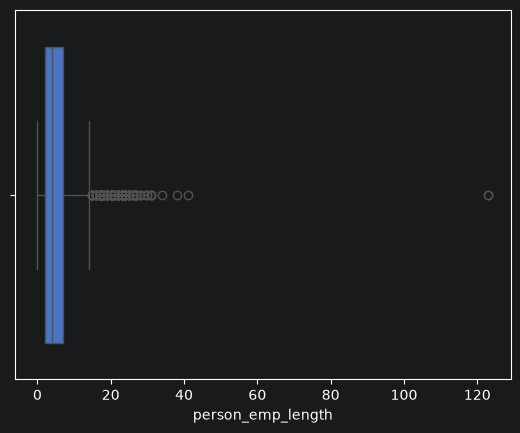

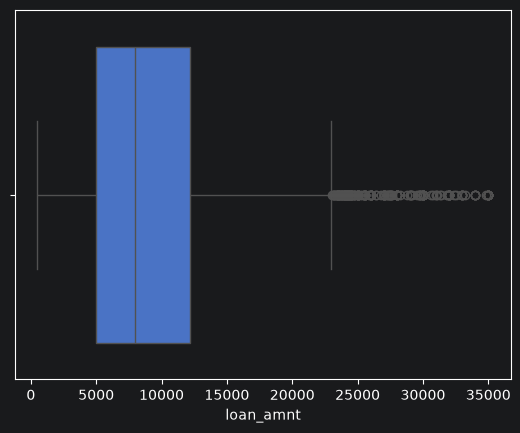

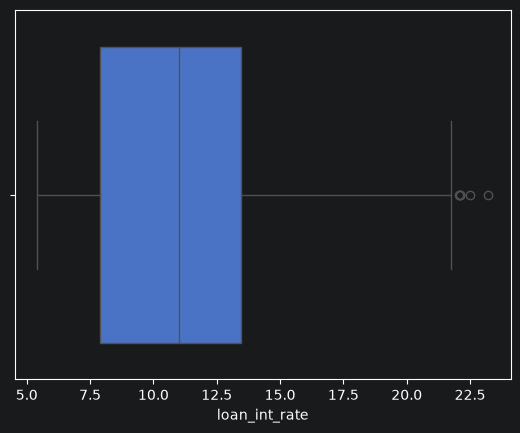

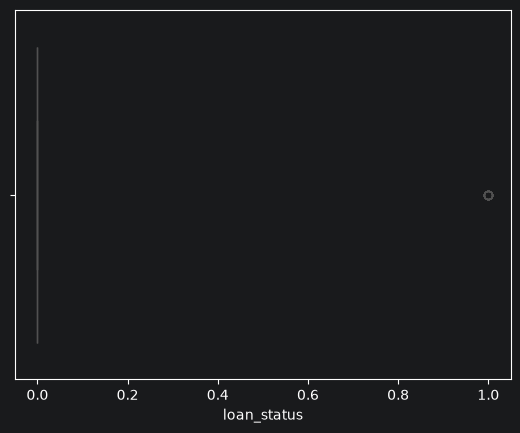

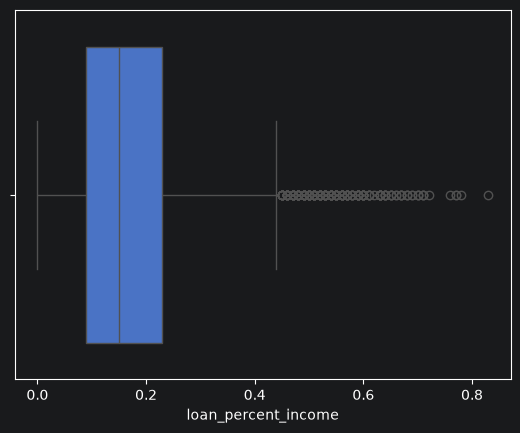

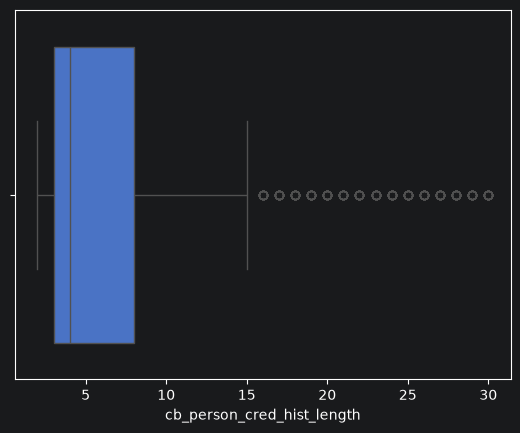

In [5]:
for i in numerical_cols:
  sns.boxplot(x=df[i])
  plt.show()

In [6]:
df[df['person_age']>100]['person_age'].value_counts()

person_age
144    3
123    2
Name: count, dtype: int64

In [7]:
(df['person_emp_length']>60).sum()

np.int64(2)

<Axes: >

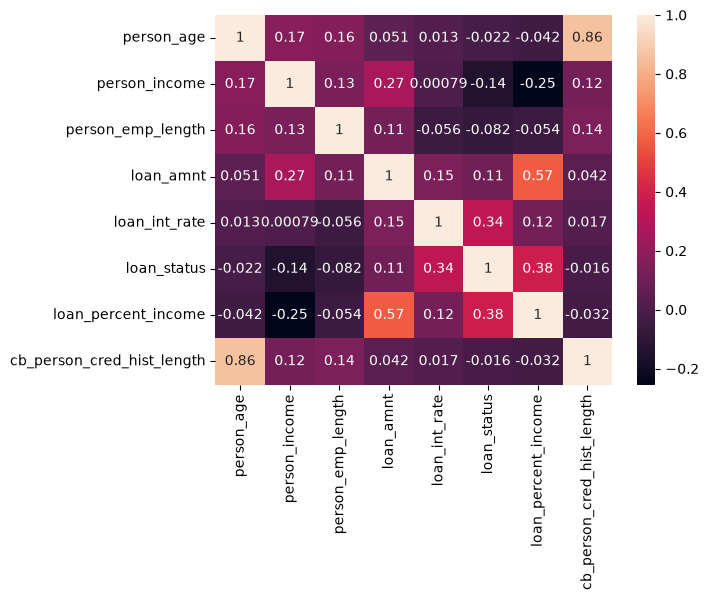

In [10]:
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data validation and Outlier handling

In [8]:
df_copy = df.copy()

print(f"Original Shape: {df_copy.shape[0]}")
# Remove Duplicate
df_copy.drop_duplicates(inplace=True)
print(f"After Removing Duplicate: {df_copy.shape[0]}")

# Remove Age Below 18 and above 100
df_copy = df_copy[df_copy['person_age']>=18]
df_copy = df_copy[df_copy['person_age']<=100]

# Remove employment length greater than age or extreme outlier (ie. >60)
df_copy = df_copy[df_copy['person_emp_length']<= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length']<=60]

df_copy = df_copy[df_copy['loan_amnt']>0]

Original Shape: 32581
After Removing Duplicate: 32416


# Features, Targets and train_test_split

In [9]:
from sklearn.model_selection import train_test_split

X = df_copy.drop('loan_status',axis=1)
y = df_copy['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
numeric_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(exclude=np.number).columns

# Handle Class imbalance

In [11]:
# Class - weights
#0 -> no loan (most)
#1 -> yes loan
# -> this is creating class imbalance

neg, pos = np.bincount(y_train)
scale_weight = neg/pos
scale_weight

np.float64(3.6312213039485766)

# 6 Data processing - Pipelines and column Transformer

In [14]:
# Preprocessing for logistic regression
# Logistic Regression : impute + scale numeric | impute + OHE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        # Pipeline for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        # Pipeline for cata columns
        ('cata', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

In [16]:
# Preprocessing for XGBoost
# XGBoost : impute numeric cols, no scaling will be performed | Impute + OHE

preprocessor_xg = ColumnTransformer(
    transformers=[
        # Pipeline for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        # Pipeline for cata columns
        ('cata', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

# 7. Evaluation Helper Function
- We build one common function to check any model's performance.
- It will show accuracy, precision, recall, F1 score, and more.
- It will also show a confusion matrix and a precision-recall curve.

In [18]:
# Evaluate Logistic Model and XGBoost model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
    precision_recall_curve
)
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  # Metrices
  accuracy = accuracy_score(y_test, y_pred) # Overall Model's preformance
  precision = precision_score(y_test, y_pred) # Of the once I picked, how many were actually right
  recall = recall_score(y_test, y_pred) # Out of everyThing that was really there, how much did you manage to find?
  f1 = f1_score(y_test, y_pred) # Harmonic mean of precision and recall


  # Confusion Metix
  cm = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  print(f"{model_name} Metrics")
  if threshold is not None:
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy: {accuracy:.2f}")
  print(f"Precision: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1: {f1:.2f}")
  print('-----------------------------------------------')
  print(f"{model_name} Classification Report:")
  print(class_report)

  # plot confusion matrix

  sns.heatmap(cm, annot=True, fmt='d')
  plt.title(f"{model_name} Confusion Matrix")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()

  # Plotting ROC-AUC curve
  precisions, recalls, tresholds = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions, label=f"{model_name} Precision-Recall Curve")
  plt.xlabel("Recall")
  plt.ylabel("Precision")


# 8 Stratified Cross Validation
- one single train test split may not be reliable.
- we split the train data into five folds instead.
- Each fold keeps the same default vs rapid ratio.
- we check the model's score across all folds.

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits= 5, shuffle=True, random_state=42)
scoring = {'roc_auc': 'roc_auc', 'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

In [20]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced',random_state=42))
])

In [21]:
# XGBoost
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator = 500, max_depth=5, learning_rate=0.01,
        scale_pos_weight=scale_weight,random_state=42, n_jobs=-1
    ))
])

In [22]:
for cv_name, pipe in ([('Logistic Regression', lr_cv_pipeline), ('XGBoost', xgb_cv_pipeline)]):
  cv_result = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
  print(cv_name)
  print(f'ROC AUC: {cv_result['test_roc_auc'].mean()*100}')
  print(f'Accuracy: {cv_result['test_accuracy'].mean()*100}')
  print(f'Precision: {cv_result['test_precision'].mean()*100}')
  print(f'Recall: {cv_result['test_recall'].mean()*100}')
  print(f'F1: {cv_result['test_f1'].mean()*100}')
  print('-----------------------------------------------')


Logistic Regression
ROC AUC: 87.05112830525306
Accuracy: 81.1594954289227
Precision: 54.48226008889891
Recall: 77.81450872359963
F1: 64.08013995933108
-----------------------------------------------
XGBoost
ROC AUC: 90.70591133746626
Accuracy: 88.10325097893248
Precision: 71.411324691306
Recall: 74.96786042240589
F1: 73.12751729760615
-----------------------------------------------


# 9.Base Line Model - Logistic Regression
- start with simple model first
- train it and check it's score on the test data

In [24]:
baseline_model = Pipeline([
    ('Preprocessor', preprocessor_lr),
    ('Classifier', LogisticRegression(class_weight="balanced"))
])
baseline_model.fit(X_train, y_train)

c:\Users\AJ GUIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                 ('cata',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                ('Classifier', LogisticRegression(class_weight='balanced'))])

Baseline Logistic Model Metrics
Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1: 0.65
-----------------------------------------------
Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



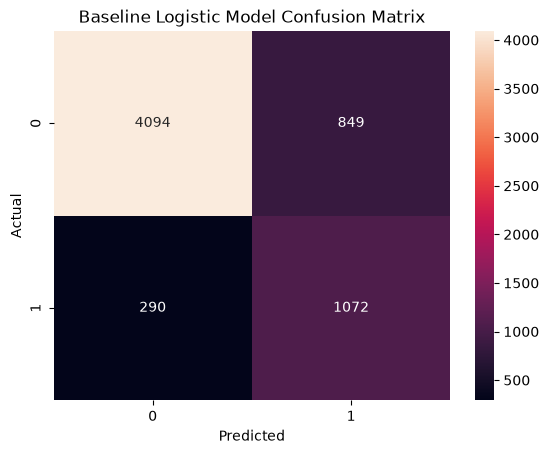

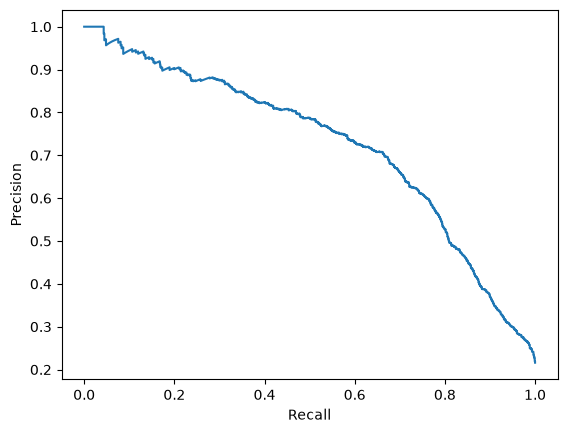

In [25]:
# Evaluate Baseline Model
evaluate_model('Baseline Logistic Model', baseline_model, X_test, y_test)

# 10. XGBoost Hyperparameter Tuning
- model has many settings called hyperparameter
- search for best combination for this settings
- use cross-validation while searching, so the result is reliable

In [62]:
xg_model = Pipeline([
    ('Preprocessor', preprocessor_xg),
    ('Classifier', XGBClassifier(learning_rate=0.1,scale_pos_weight=scale_weight, random_state=42))
])
xg_model.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                 ('cata',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='mi...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
param_grid = {
    "Classifier__n_estimators": randint(150,600),
    "Classifier__max_depth": randint(3,9),
    "Classifier__learning_rate": uniform(0.01,0.5),
    "Classifier__subsample": uniform(0.6,0.4), # Rows Sampling
    "Classifier__colsample_bytree": uniform(0.6,0.4), # Cols Sampling
    "Classifier__min_child_weight": randint(1,10),
    "Classifier__gamma": uniform(0,5)
}
# lower gamma -> more splits -> high overfitting
# higher gamma -> less splits -> low overfitting

In [28]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv = cv,
    scoring = "average_precision",
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('Preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_...
                                        'Classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021C6A7A4CD0>,
                                        'Classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021C6A66F770>,
                                        'Classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000021C6A7A4550>},
                   scoring='average_precision', verbose=1)

XGBoost hyperparameter model Metrics
Accuracy: 0.92
Precision: 0.82
Recall: 0.81
F1: 0.82
-----------------------------------------------
XGBoost hyperparameter model Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4943
           1       0.82      0.81      0.82      1362

    accuracy                           0.92      6305
   macro avg       0.89      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



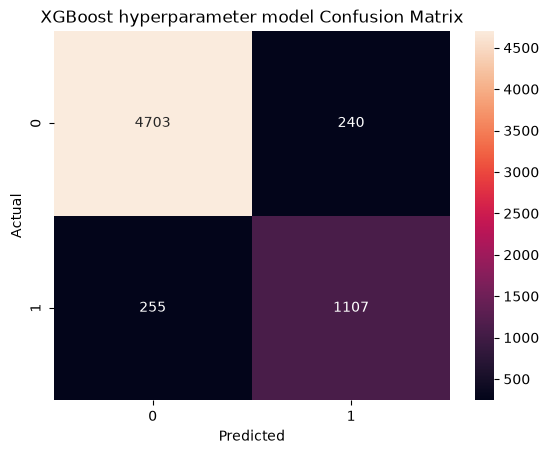

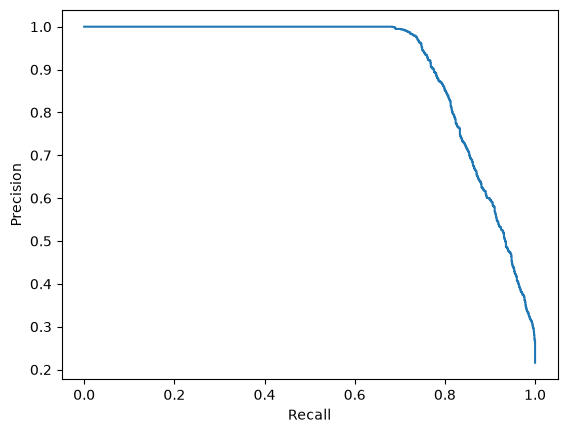

In [29]:
evaluate_model("XGBoost hyperparameter model", random_search, X_test, y_test)

# 12. Optimizing the classification Threshold
- the model gives a probability, not a direct yes or no
- decide a cut-off point to turn it into a decision
- check different cut-off point and check the best one  

XGBoost hyperparameter model Metrics
Used Threshold : 1.00
Accuracy: 0.78
Precision: 0.00
Recall: 0.00
F1: 0.00
-----------------------------------------------
XGBoost hyperparameter model Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4943
           1       0.00      0.00      0.00      1362

    accuracy                           0.78      6305
   macro avg       0.39      0.50      0.44      6305
weighted avg       0.61      0.78      0.69      6305



c:\Users\AJ GUIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\AJ GUIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\AJ GUIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modi

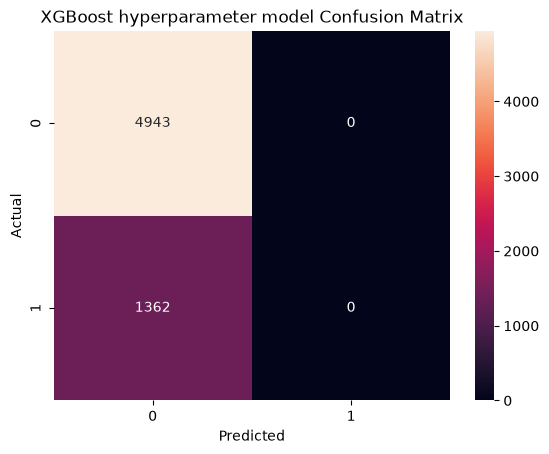

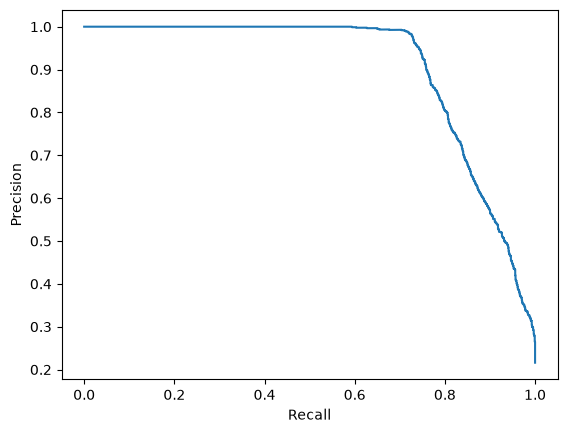

In [30]:
# Get the prob. of class '1' from XGBoost
prob = xg_model.predict_proba(X_test)[:,1]

# for each threshold calculate precision and recall
precisions, recalls, thresholds = precision_recall_curve(y_test, prob)

# Calculate F1 score for each threshold
f1 = 2*(precisions-recalls)/(precisions+recalls+ 1e-9)

# get the threshold that produce the highest F1 score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]
# Evaluate the XGBoost model using that threshold
evaluate_model("XGBoost hyperparameter model", xg_model, X_test, y_test, best_threshold)

# 13 Probability Calibration
- Sometimes a model's probability doesn't mean what it says
- for example, 30% risk should truly mean a 30% chance
- check this with calibration plot
- we fix ot if the probabilities are off

In [31]:
"""
Methods to handle poor calibration
1. Platt Scaling/ Sigmoid -> adjust the probability using the sigmoid curve (good for small data)
2. Isotonic Regression -> learn flexible  mapping from old probability to better probability
3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature
"""

'\nMethods to handle poor calibration\n1. Platt Scaling/ Sigmoid -> adjust the probability using the sigmoid curve (good for small data)\n2. Isotonic Regression -> learn flexible  mapping from old probability to better probability\n3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature\n'

In [32]:
# Calibrated XGBoost Model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=5
)
calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('Preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                                                  ('cata',
                                                                                   Pipeline(steps=[(...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.10757036005903779),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=9,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=279,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [33]:
# Get Probabilities
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

In [34]:
# create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins=10)

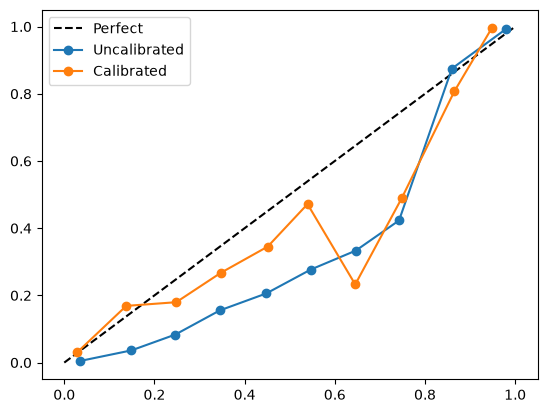

In [35]:
# Plotting
plt.plot([0,1],[0,1], 'k--', label= 'Perfect')
plt.plot(
    predicted_uncal,
    actual_uncal,
    'o-',
    label = 'Uncalibrated'
)
plt.plot(
    predicted_cal,
    actual_cal,
    'o-',
    label = 'Calibrated'
)
plt.legend()


# SHAP Interpretation Global & Local
- shap help us know why the model makes a perticular decision
- way of explaining a "black box" model



In [39]:
import shap
# Get the trained XGBoost classifier model out of the pipeline
xgb_classifier = xg_model.named_steps['Classifier']

In [40]:
# transform X_test using the same preprocessing used for training
X_test_transformed = xg_model.named_steps['Preprocessor'].transform(X_test)

In [41]:
# Get feature name after OHE encoding, so plots are reliable
feature_names = xg_model.named_steps['Preprocessor'].get_feature_names_out()

In [42]:
# Convert to dataframe for clean SHAP plot
X_test_df = pd.DataFrame(X_test_transformed, columns = feature_names)

In [43]:
# create SHAP explainer build for tree based model
explainer = shap.TreeExplainer(xgb_classifier)

In [44]:
# Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)

## Global Explanation
- shows which features matters overall in the model
- it also showes if a feature increases  or decreases risk

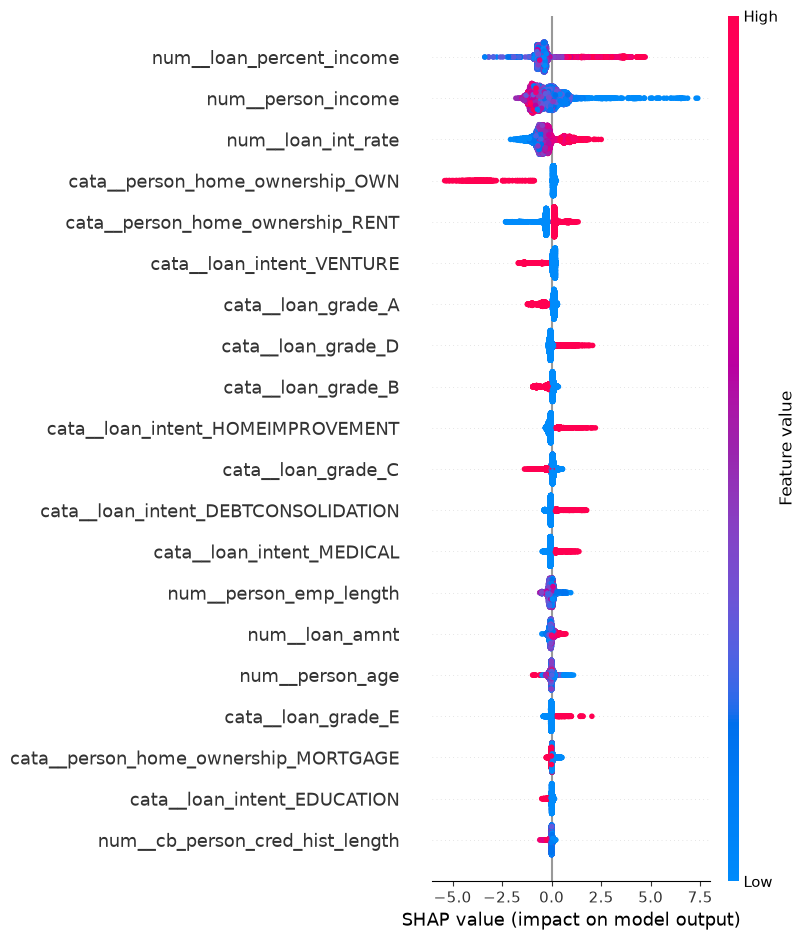

In [45]:
shap.summary_plot(shap_values, X_test_df)

## Local explainations
- This shows why one specific applicant got their score
- it breaks the score feature by feature

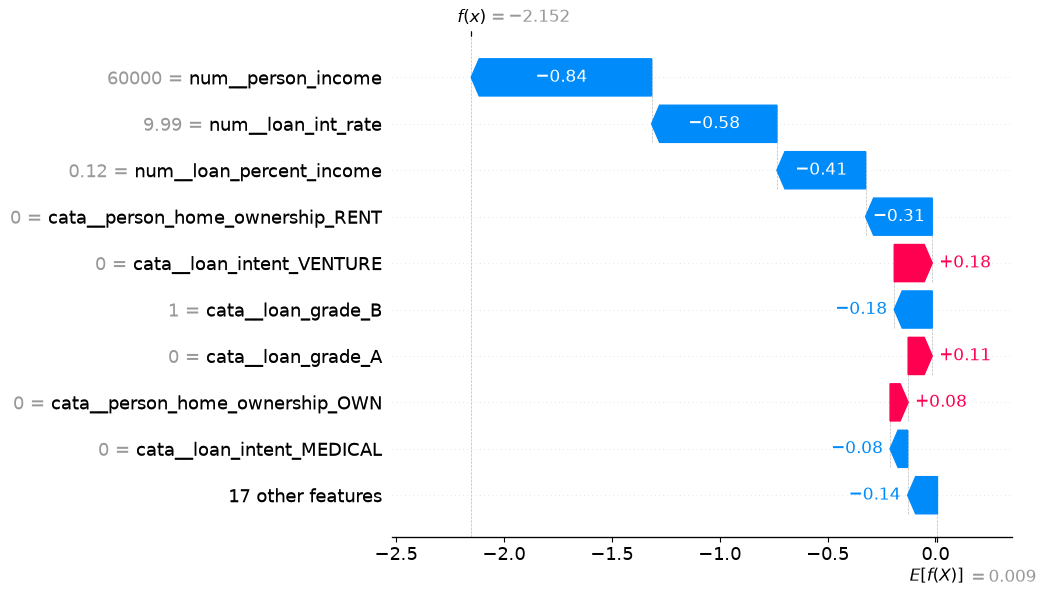

In [46]:
# pic one row to understand, e.g take 5th applicant
row_index = 5
# Draw a waterfall plot showing how each feature pushed the prediction
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

# Analysis of false Postive ans false Negative
- False positive are safe people marker risky
- False Negative are risky people marker safe

In [57]:
# get predictions from the best performing XGBoost model on the test set
y_pred = random_search.predict(X_test)

In [58]:
# Create a Dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [59]:

#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual']== 0) & (result_df['predicted']== 1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual']== 1) & (result_df['predicted']== 0)]

In [60]:
print(f"false positive: {len(false_positive)}")
print(f"false negative: {len(false_negative)}")

false positive: 240
false negative: 255


In [61]:
# false negative > false positive

# Final -> saving of the final model

In [63]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [65]:
from sklearn.metrics import precision_recall_curve
import numpy as np

calibrated_prob = calibrated_model.predict_proba(X_test)[:,1]
precisions, recalls, thresholds = precision_recall_curve(y_test, calibrated_prob)
f1 = 2*(precisions*recalls)/(precisions+recalls+1e-9)
best_threshold = thresholds[np.argmax(f1[:-1])]
print(best_threshold)

0.7351809305610242


In [66]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']